# Cosmetics Dataset — Machine Learning Price Prediction

**Course:** Machine Learning  
**Dataset:** cosmetics_dataset.xlsx  
**Student:** Sepehr Shoja  
**Student Number:** 40311466013

---

### Objective
Predict the **final price** (`final_price_toman`) of cosmetic products using product
characteristics — **without** using `price_toman` or `discount_percent` (which together
define the target through a deterministic formula and would constitute data leakage).

### Models Evaluated
| # | Model | Library |
|---|-------|---------|
| 1 | Random Forest Regressor | scikit-learn |
| 2 | XGBoost Regressor | xgboost |
| 3 | CatBoost Regressor | catboost |


## 0. Imports & Global Settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import gridspec
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ── Global style ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

PALETTE      = "viridis"
FIGSIZE_SM   = (7, 4)
FIGSIZE_MD   = (10, 5)
FIGSIZE_LG   = (13, 6)
FIGSIZE_XL   = (15, 8)
RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("Libraries loaded | RandomizedSearchCV ready")

Libraries loaded | RandomizedSearchCV ready


## 1. Data Loading & Overview

### 1.1 Load Dataset

In [2]:
df = pd.read_excel("cosmetics_dataset.xlsx")

# Parse date columns
for col in ["created_at", "updated_at"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")

Shape   : 1,000 rows × 22 columns
Columns : ['product_id', 'sku', 'brand', 'product_name_fa', 'category', 'sub_category', 'variant', 'target_area', 'skin_type', 'size_value', 'size_unit', 'origin_country', 'price_toman', 'discount_percent', 'final_price_toman', 'stock_qty', 'rating', 'review_count', 'seller', 'availability', 'created_at', 'updated_at']


### 1.2 Shape, Data Types & Sample Rows

In [3]:
print("=== dtypes ===")
print(df.dtypes.to_string())
print()
print("=== First 5 rows ===")
df.head()

=== dtypes ===
product_id                   object
sku                          object
brand                        object
product_name_fa              object
category                     object
sub_category                 object
variant                      object
target_area                  object
skin_type                    object
size_value                    int64
size_unit                    object
origin_country               object
price_toman                   int64
discount_percent            float64
final_price_toman             int64
stock_qty                     int64
rating                      float64
review_count                  int64
seller                       object
availability                 object
created_at           datetime64[ns]
updated_at           datetime64[ns]

=== First 5 rows ===


,product_id,sku,brand,product_name_fa,category,sub_category,variant,target_area,skin_type,size_value,...,price_toman,discount_percent,final_price_toman,stock_qty,rating,review_count,seller,availability,created_at,updated_at
0,COS0001,آرد-MOIS-0001,آردن,آردن مرطوب‌کننده آبرسان,Skincare,Moisturizer,آبرسان,face,dry,75,...,668000,0.05,634600,65,4.4,29,khanoumi_marketplace,available,2025-09-08,2025-09-14
1,COS0002,لاف-COND-0002,لافارر,لافارر کرم نرم‌کننده آبرسان,Haircare,Conditioner,آبرسان,hair,damaged,300,...,357000,0.15,303450,69,4.7,90,cosmetic_bazaar,available,2025-01-24,2025-03-14
2,COS0003,اسن-SETT-0003,اسنس,اسنس اسپری فیکس ماندگاری بالا,Makeup,Setting Spray,بدون رنگ,face,oily,50,...,593000,0.12,521840,104,4.0,195,official_store,available,2025-12-22,2025-12-30
3,COS0004,ژنو-MICE-0004,ژنوبایوتیک,ژنوبایوتیک میسلار واتر پاک‌کننده آرایش,Skincare,Micellar Water,پاک‌کننده آرایش,face,dry,250,...,539000,0.15,458150,96,4.7,132,official_store,available,2025-11-30,2026-02-20
4,COS0005,کام-TONE-0005,کامان,کامان تونر صورت تسکین‌دهنده,Skincare,Toner,تسکین‌دهنده,face,sensitive,150,...,428000,0.15,363800,117,3.9,42,cosmetic_bazaar,available,2024-08-04,2026-03-07


### 1.3 Missing Value Check

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

if missing_df.empty:
    print("✓ No missing values found in the dataset.")
else:
    print(missing_df)

✓ No missing values found in the dataset.


### 1.4 Descriptive Statistics

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,1000,1000,COS1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sku,1000,1000,ویش-SERU-1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,1000,33,نئودرم,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_fa,1000,879,نیوآ اسپری خوشبوکننده بدن رایحه میوه,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1000,4,Skincare,472,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_category,1000,30,Moisturizer,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variant,1000,72,آبرسان,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_area,1000,8,face,493,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skin_type,1000,8,all,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_value,1000.0,NaN,NaN,NaN,94.935,1.0,15.0,50.0,150.0,400.0,104.500378


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Variable — Final Price Distribution

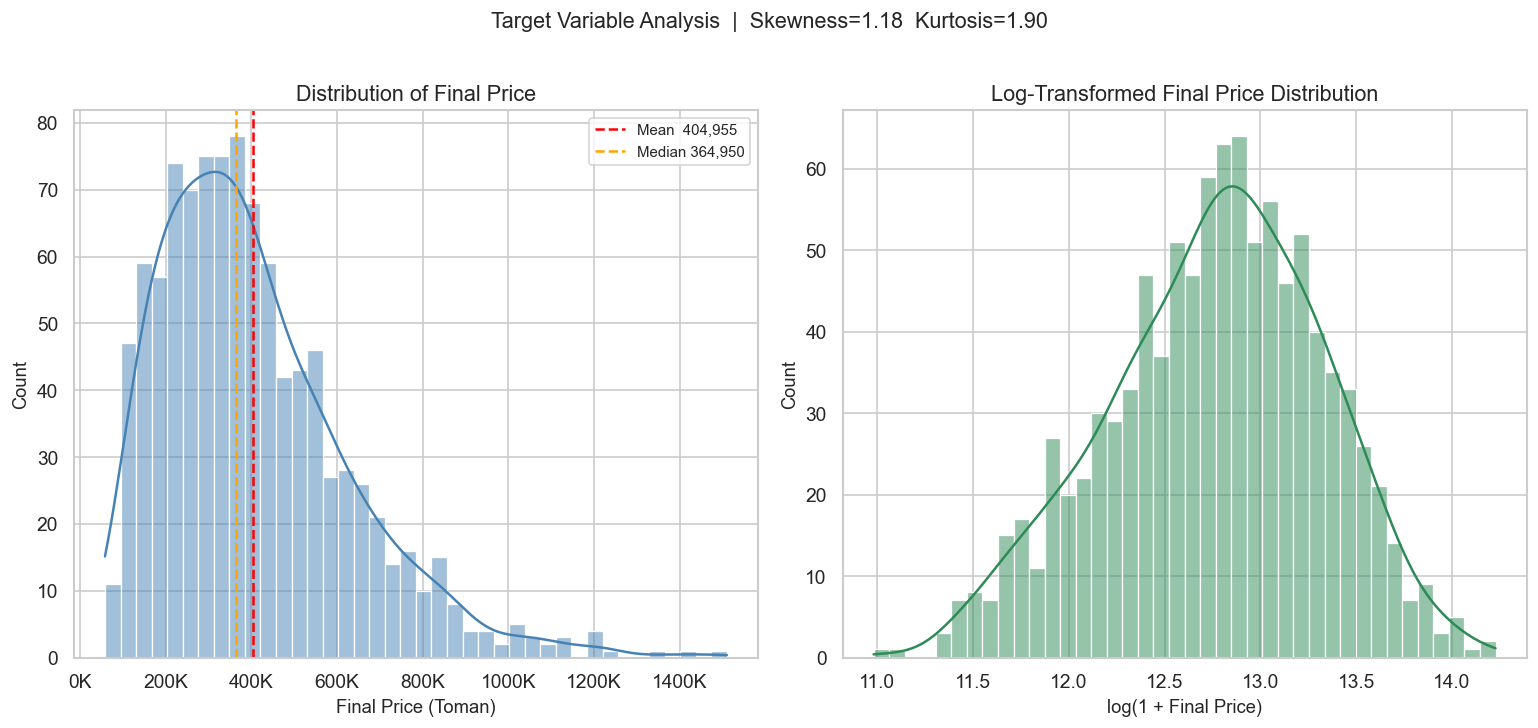

Min  :       58,800 Toman
Max  :    1,509,550 Toman
Mean :      404,955 Toman
Std  :      221,695 Toman


In [6]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# Histogram + KDE
ax = axes[0]
sns.histplot(df["final_price_toman"], bins=40, kde=True,
             color="steelblue", edgecolor="white", ax=ax)
ax.axvline(df["final_price_toman"].mean(),   color="red",    ls="--", lw=1.5, label=f"Mean  {df['final_price_toman'].mean():,.0f}")
ax.axvline(df["final_price_toman"].median(), color="orange", ls="--", lw=1.5, label=f"Median {df['final_price_toman'].median():,.0f}")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Final Price (Toman)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Final Price")
ax.legend(fontsize=9)

# Log-scale histogram
ax2 = axes[1]
log_prices = np.log1p(df["final_price_toman"])
sns.histplot(log_prices, bins=40, kde=True, color="seagreen", edgecolor="white", ax=ax2)
ax2.set_xlabel("log(1 + Final Price)")
ax2.set_ylabel("Count")
ax2.set_title("Log-Transformed Final Price Distribution")

skew_val = df["final_price_toman"].skew()
kurt_val = df["final_price_toman"].kurt()
fig.suptitle(f"Target Variable Analysis  |  Skewness={skew_val:.2f}  Kurtosis={kurt_val:.2f}",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Min  : {df['final_price_toman'].min():>12,.0f} Toman")
print(f"Max  : {df['final_price_toman'].max():>12,.0f} Toman")
print(f"Mean : {df['final_price_toman'].mean():>12,.0f} Toman")
print(f"Std  : {df['final_price_toman'].std():>12,.0f} Toman")

### 2.2 Final Price by Category

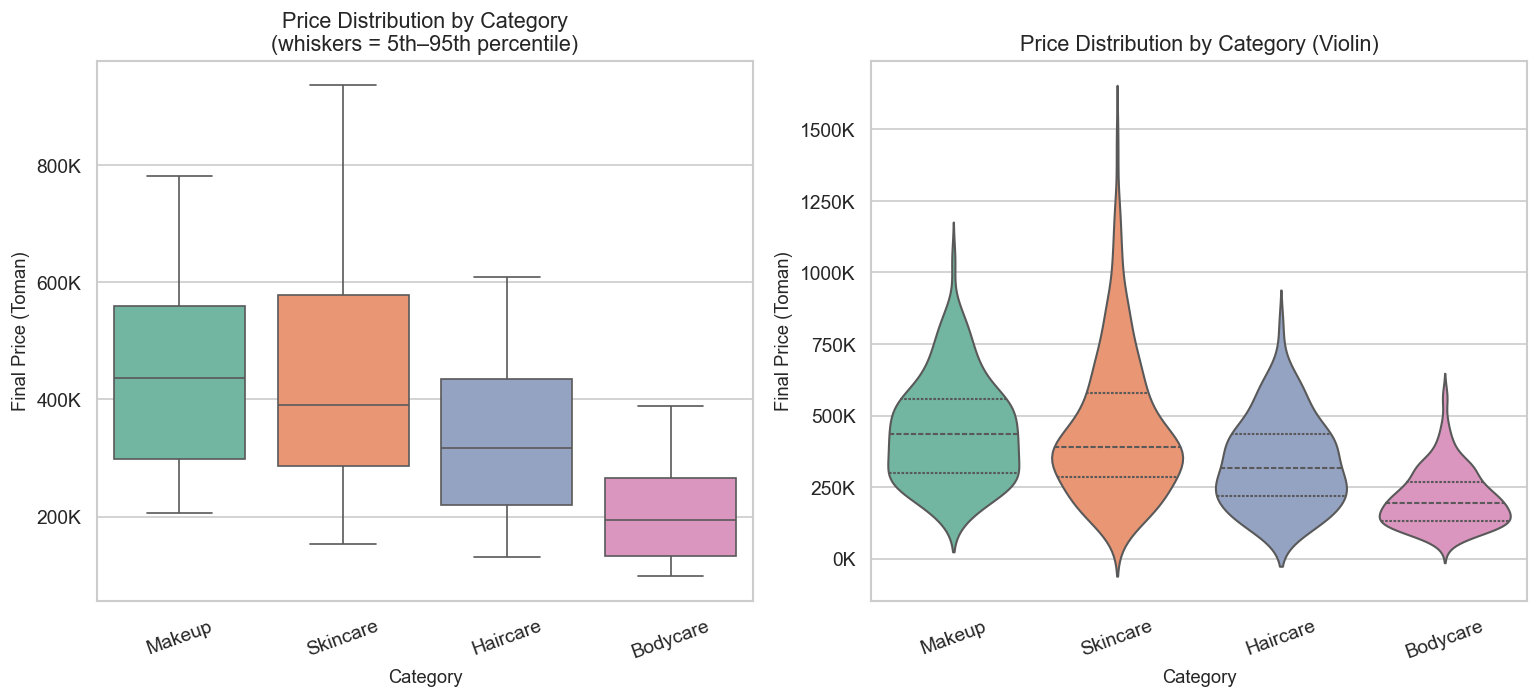

In [7]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# Box plot
ax = axes[0]
cat_order = df.groupby("category")["final_price_toman"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="category", y="final_price_toman",
            order=cat_order, palette="Set2",
            showfliers=False, whis=[5, 95], ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Category")
ax.set_ylabel("Final Price (Toman)")
ax.set_title("Price Distribution by Category\n(whiskers = 5th–95th percentile)")
ax.tick_params(axis="x", rotation=20)

# Violin plot
ax2 = axes[1]
sns.violinplot(data=df, x="category", y="final_price_toman",
               order=cat_order, palette="Set2",
               inner="quartile", ax=ax2)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax2.set_xlabel("Category")
ax2.set_ylabel("Final Price (Toman)")
ax2.set_title("Price Distribution by Category (Violin)")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 2.3 Final Price by Origin Country

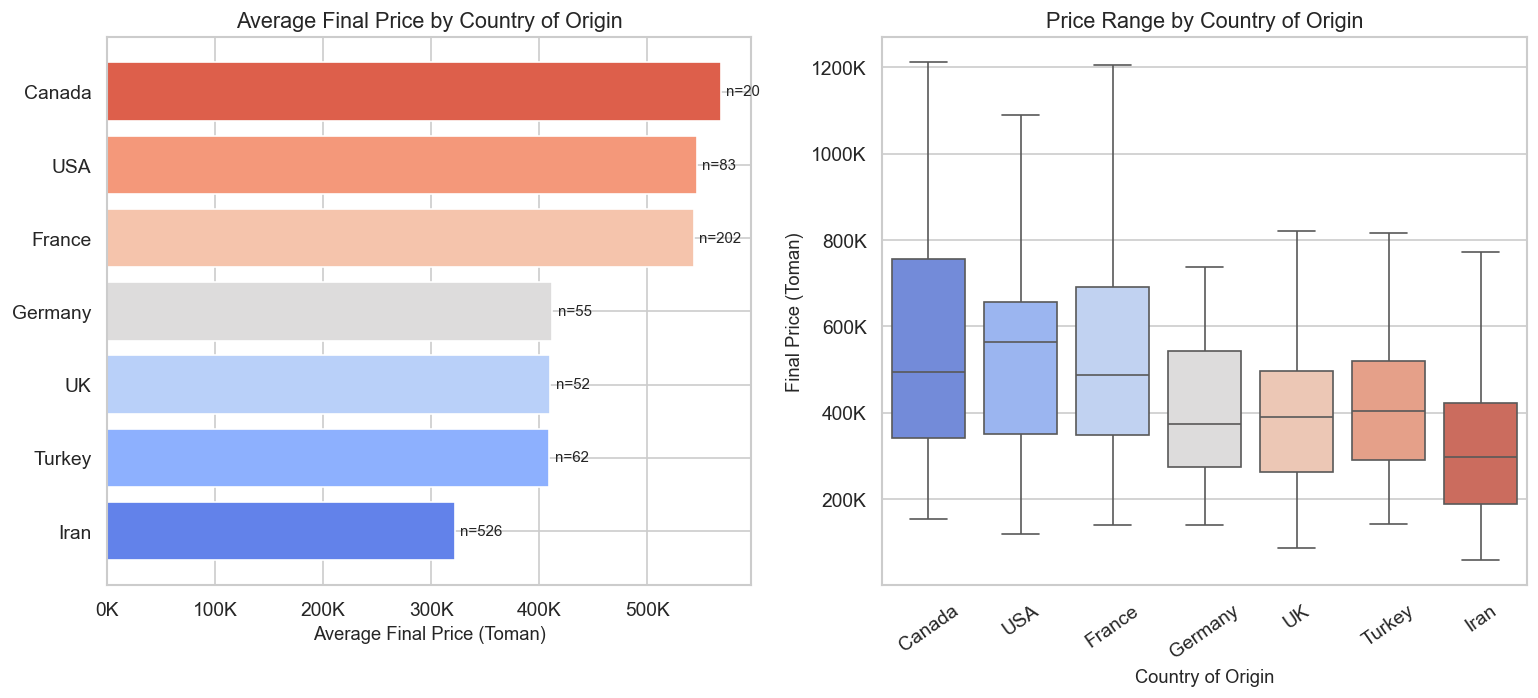

In [8]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# Average price by country
country_stats = (
    df.groupby("origin_country")["final_price_toman"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

ax = axes[0]
colors = sns.color_palette("coolwarm", len(country_stats))
bars = ax.barh(country_stats["origin_country"][::-1],
               country_stats["mean"][::-1],
               color=colors, edgecolor="white")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Average Final Price (Toman)")
ax.set_title("Average Final Price by Country of Origin")
for bar, (_, row) in zip(bars, country_stats[::-1].iterrows()):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f"n={int(row['count'])}", va="center", fontsize=9)

# Box plot by country
ax2 = axes[1]
country_order = country_stats["origin_country"].tolist()
sns.boxplot(data=df, x="origin_country", y="final_price_toman",
            order=country_order, palette="coolwarm",
            showfliers=False, ax=ax2)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax2.set_xlabel("Country of Origin")
ax2.set_ylabel("Final Price (Toman)")
ax2.set_title("Price Range by Country of Origin")
ax2.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### 2.5 Sub-Category Price Analysis

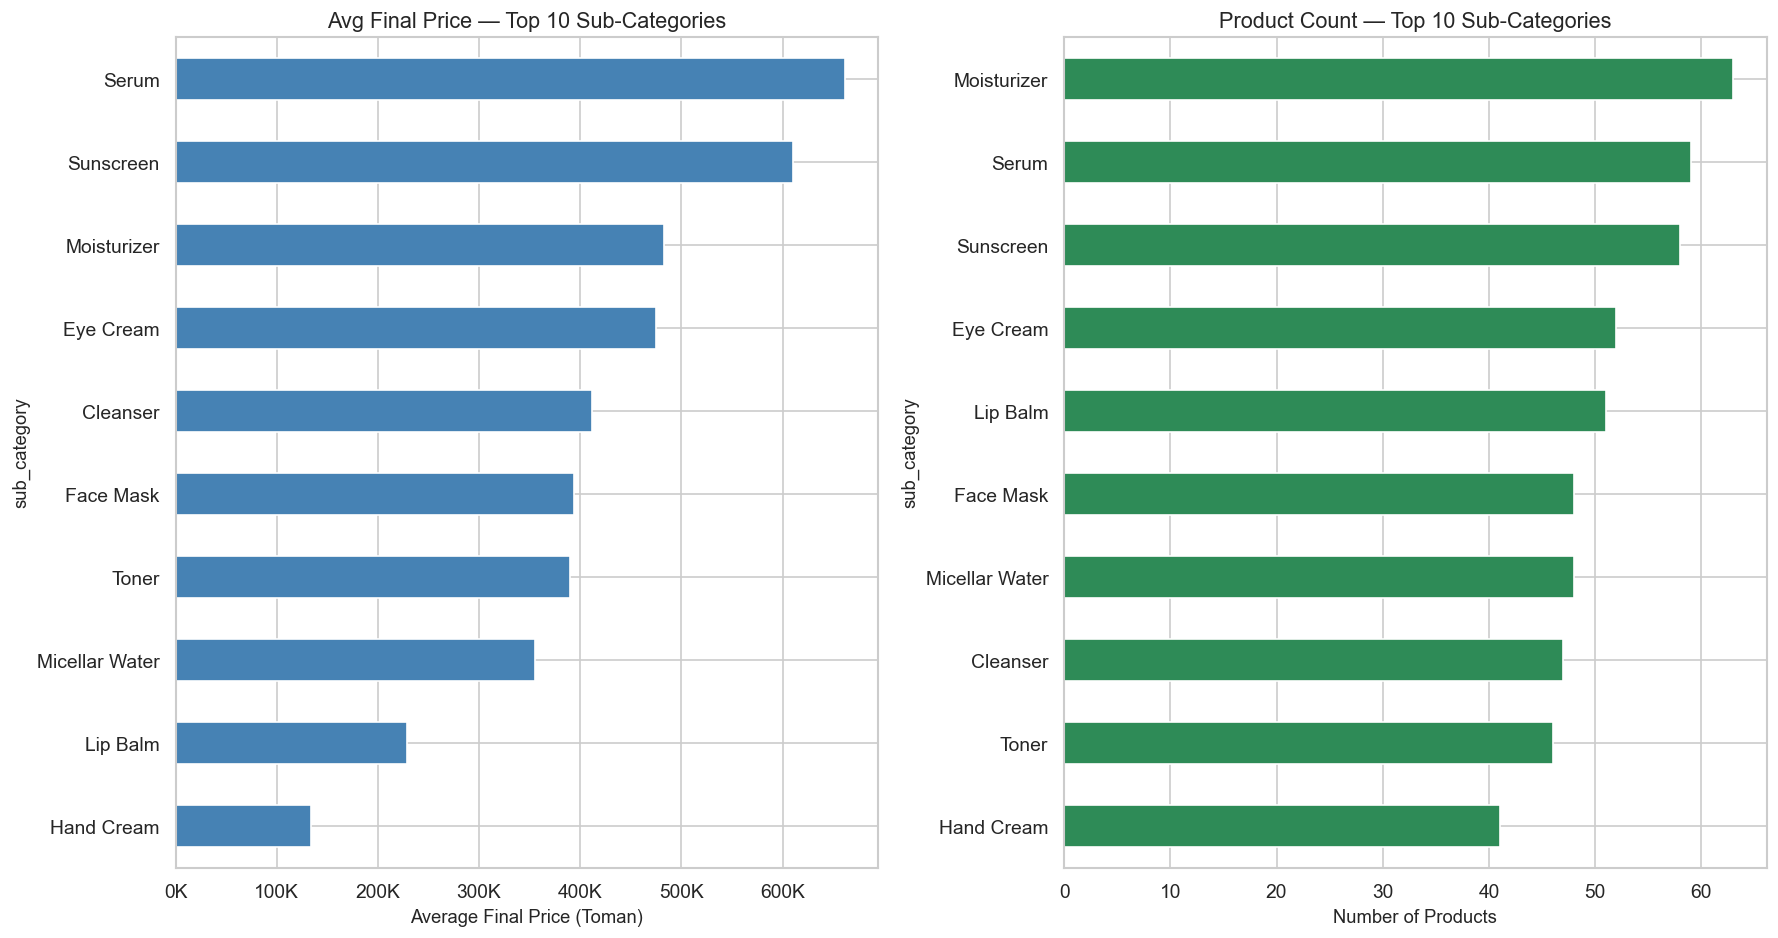

In [9]:
# Top 15 sub-categories by count
top_sub = df["sub_category"].value_counts().head(10).index

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_XL)

# Average price
sub_avg = (
    df[df["sub_category"].isin(top_sub)]
    .groupby("sub_category")["final_price_toman"]
    .mean()
    .sort_values(ascending=True)
)
ax = axes[0]
sub_avg.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Average Final Price (Toman)")
ax.set_title("Avg Final Price — Top 10 Sub-Categories")

# Count
ax2 = axes[1]
sub_cnt = df[df["sub_category"].isin(top_sub)]["sub_category"].value_counts()
sub_cnt.sort_values().plot(kind="barh", ax=ax2, color="seagreen", edgecolor="white")
ax2.set_xlabel("Number of Products")
ax2.set_title("Product Count — Top 10 Sub-Categories")

plt.tight_layout()
plt.show()

### 2.8 Price by Skin Type & Target Area

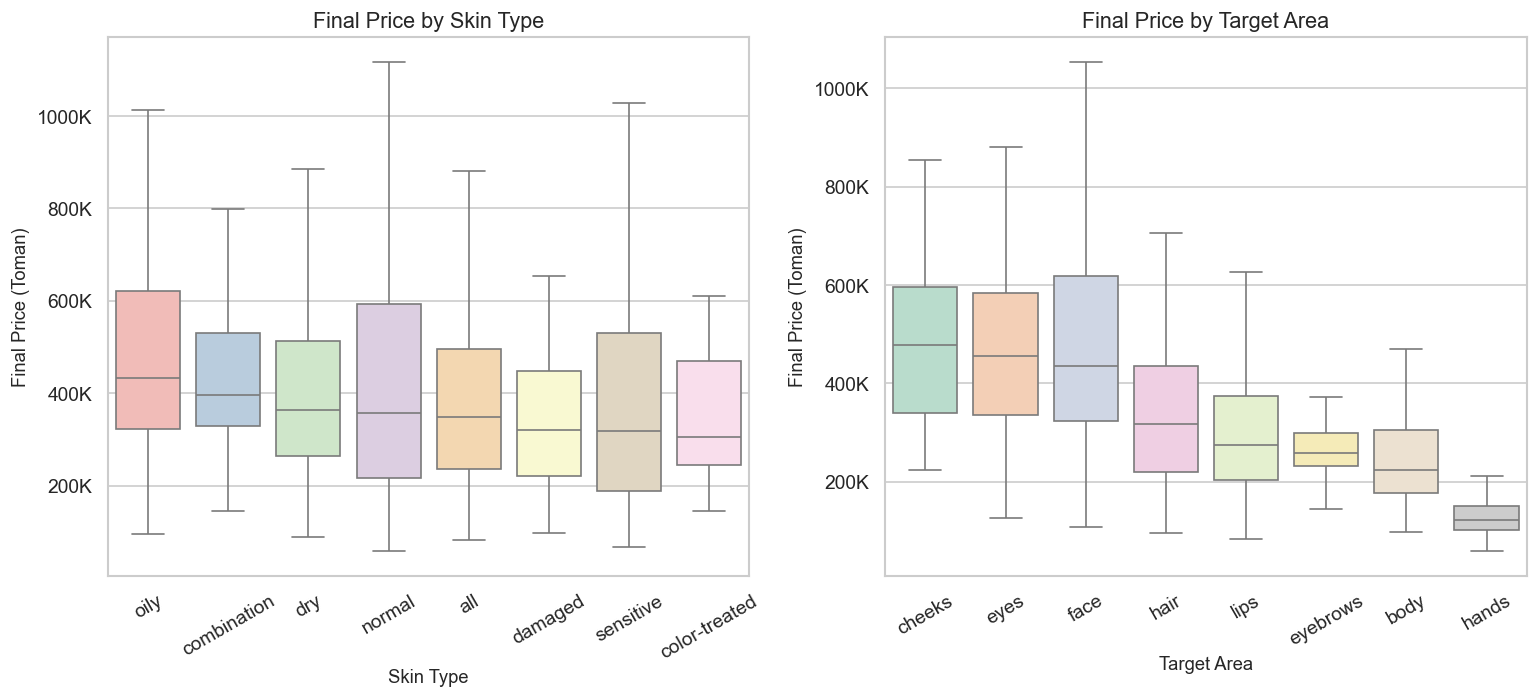

In [10]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# Skin type
ax = axes[0]
skin_order = df.groupby("skin_type")["final_price_toman"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="skin_type", y="final_price_toman",
            order=skin_order, palette="Pastel1",
            showfliers=False, ax=ax)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_title("Final Price by Skin Type")
ax.tick_params(axis="x", rotation=30)
ax.set_xlabel("Skin Type")
ax.set_ylabel("Final Price (Toman)")

# Target area
ax2 = axes[1]
area_order = df.groupby("target_area")["final_price_toman"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="target_area", y="final_price_toman",
            order=area_order, palette="Pastel2",
            showfliers=False, ax=ax2)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax2.set_title("Final Price by Target Area")
ax2.tick_params(axis="x", rotation=30)
ax2.set_xlabel("Target Area")
ax2.set_ylabel("Final Price (Toman)")

plt.tight_layout()
plt.show()

### 2.9 Categorical Feature Count Distributions

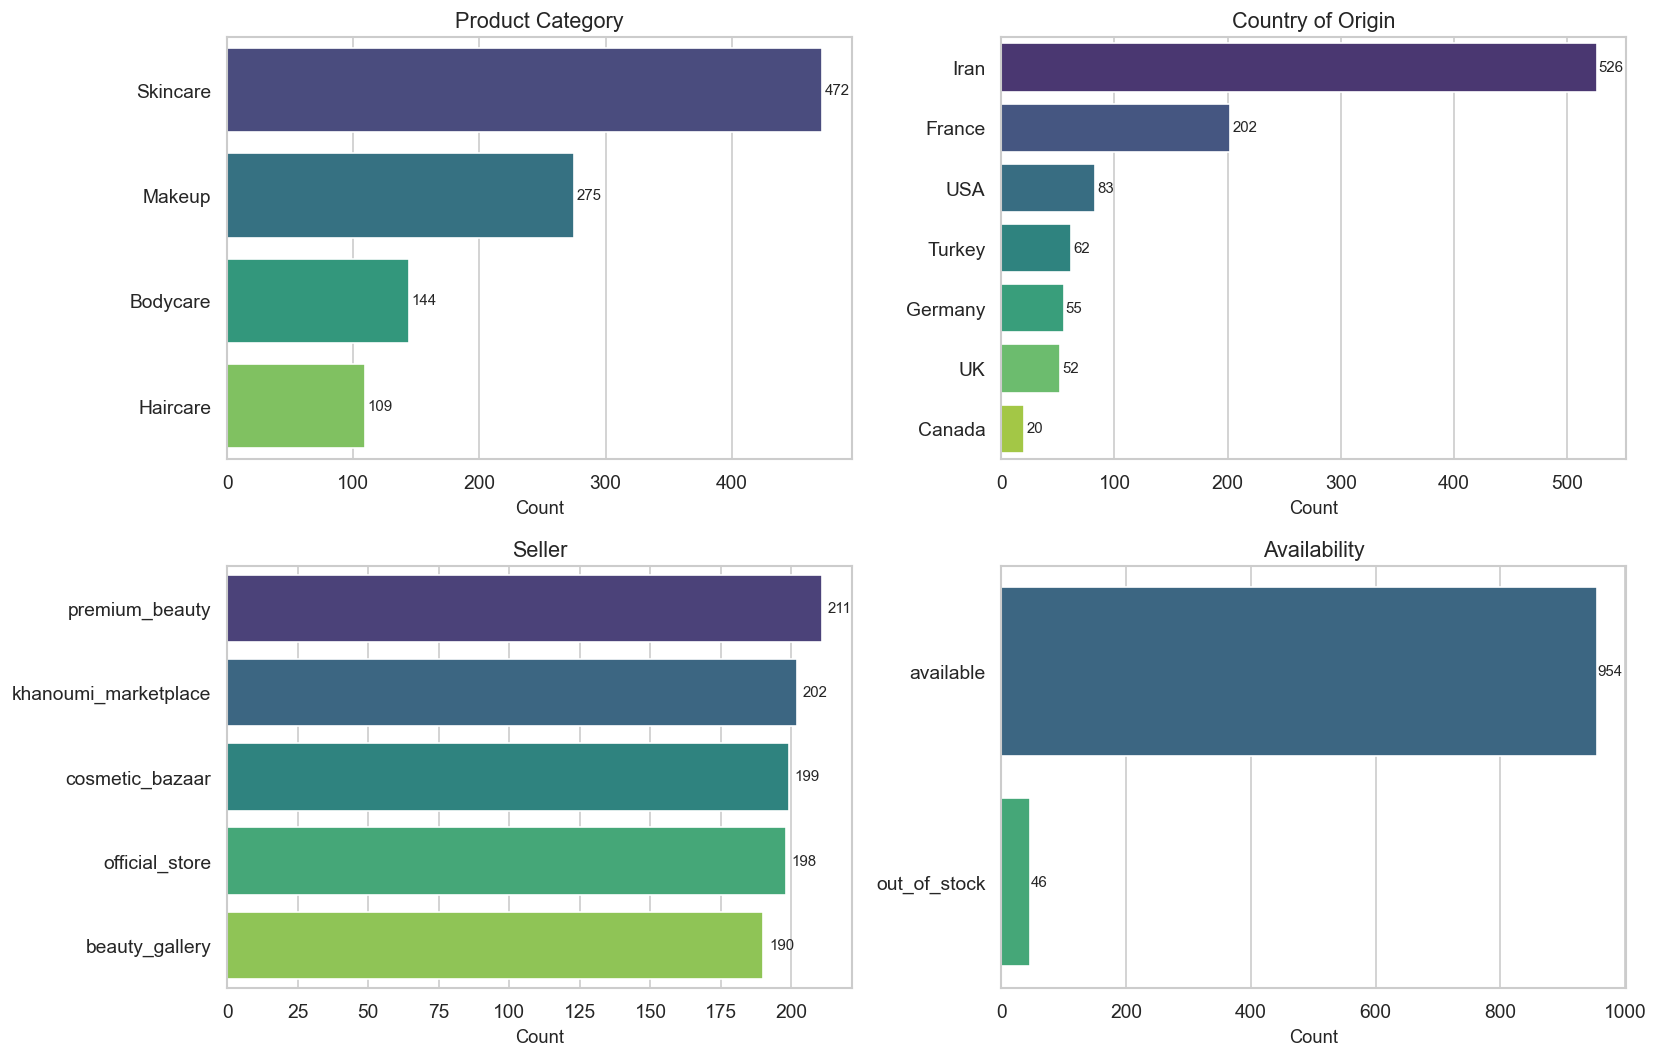

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

cat_to_plot = [
    ("category",       "Product Category"),
    ("origin_country", "Country of Origin"),
    ("seller",         "Seller"),
    ("availability",   "Availability"),
]

for ax, (col, title) in zip(axes.flat, cat_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order,
                  palette="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    for bar in ax.patches:
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f"{int(bar.get_width())}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 2.10 Size Value vs Final Price

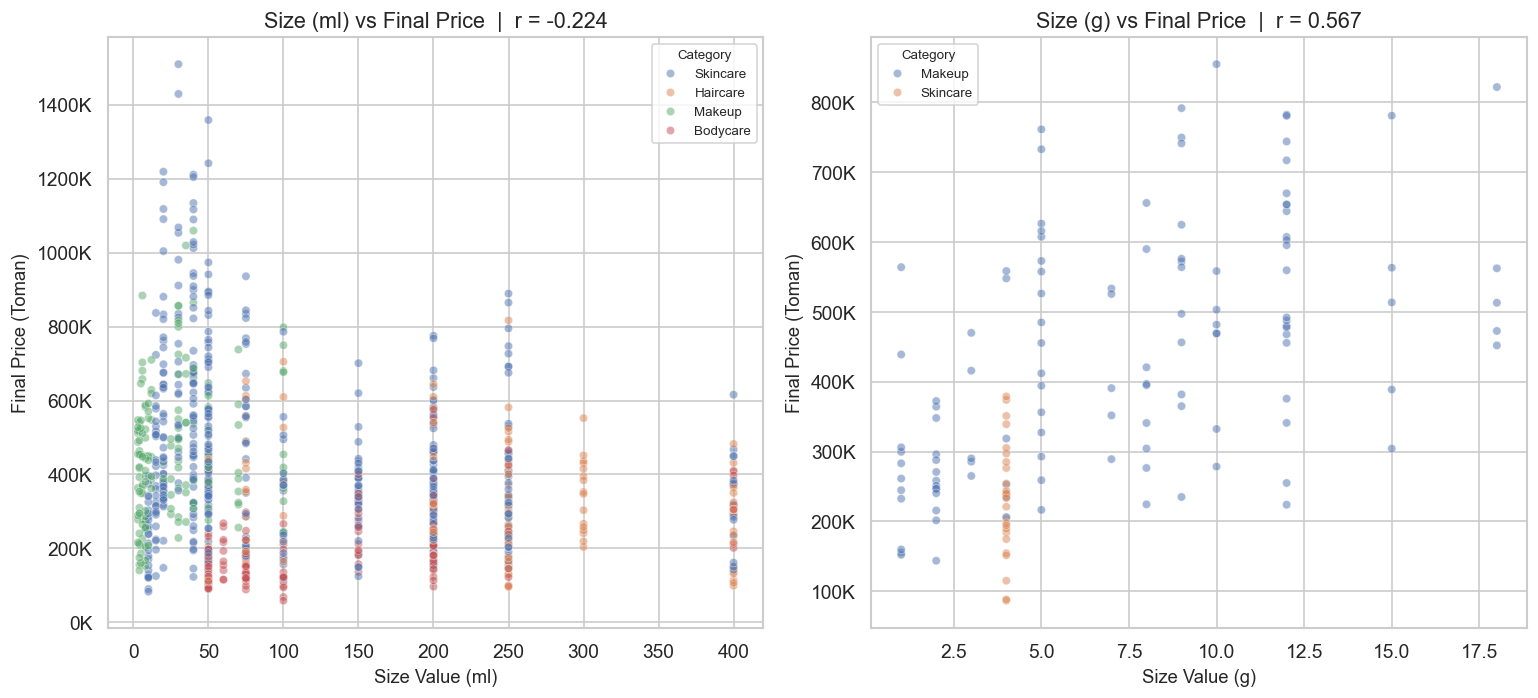

In [12]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_LG)

# ml products
ax = axes[0]
ml_data = df[df["size_unit"] == "ml"]
sns.scatterplot(data=ml_data, x="size_value", y="final_price_toman",
                hue="category", alpha=0.5, s=25, ax=ax)
corr_ml = ml_data["size_value"].corr(ml_data["final_price_toman"])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_title(f"Size (ml) vs Final Price  |  r = {corr_ml:.3f}")
ax.set_xlabel("Size Value (ml)")
ax.set_ylabel("Final Price (Toman)")
ax.legend(title="Category", fontsize=8, title_fontsize=8)

# g products
ax2 = axes[1]
g_data = df[df["size_unit"] == "g"]
sns.scatterplot(data=g_data, x="size_value", y="final_price_toman",
                hue="category", alpha=0.5, s=25, ax=ax2)
corr_g = g_data["size_value"].corr(g_data["final_price_toman"])
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax2.set_title(f"Size (g) vs Final Price  |  r = {corr_g:.3f}")
ax2.set_xlabel("Size Value (g)")
ax2.set_ylabel("Final Price (Toman)")
ax2.legend(title="Category", fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

### 3.1 Pearson Correlation — Numeric Features

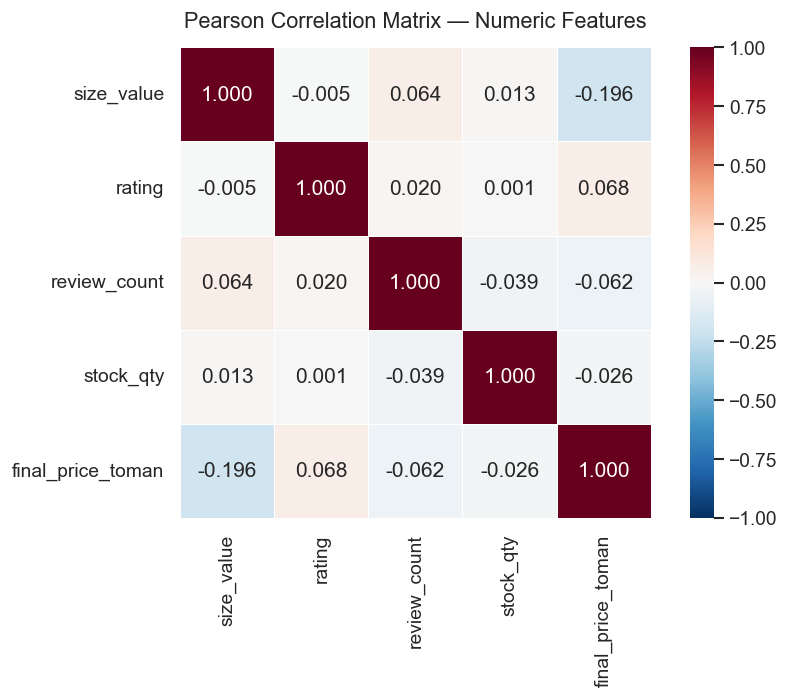

In [13]:
numeric_cols = ["size_value", "rating", "review_count", "stock_qty",
               "final_price_toman"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)
ax.set_title("Pearson Correlation Matrix — Numeric Features", pad=12)
plt.tight_layout()
plt.show()

### 3.2 Full Encoded Correlation Heatmap (All Selected Features)

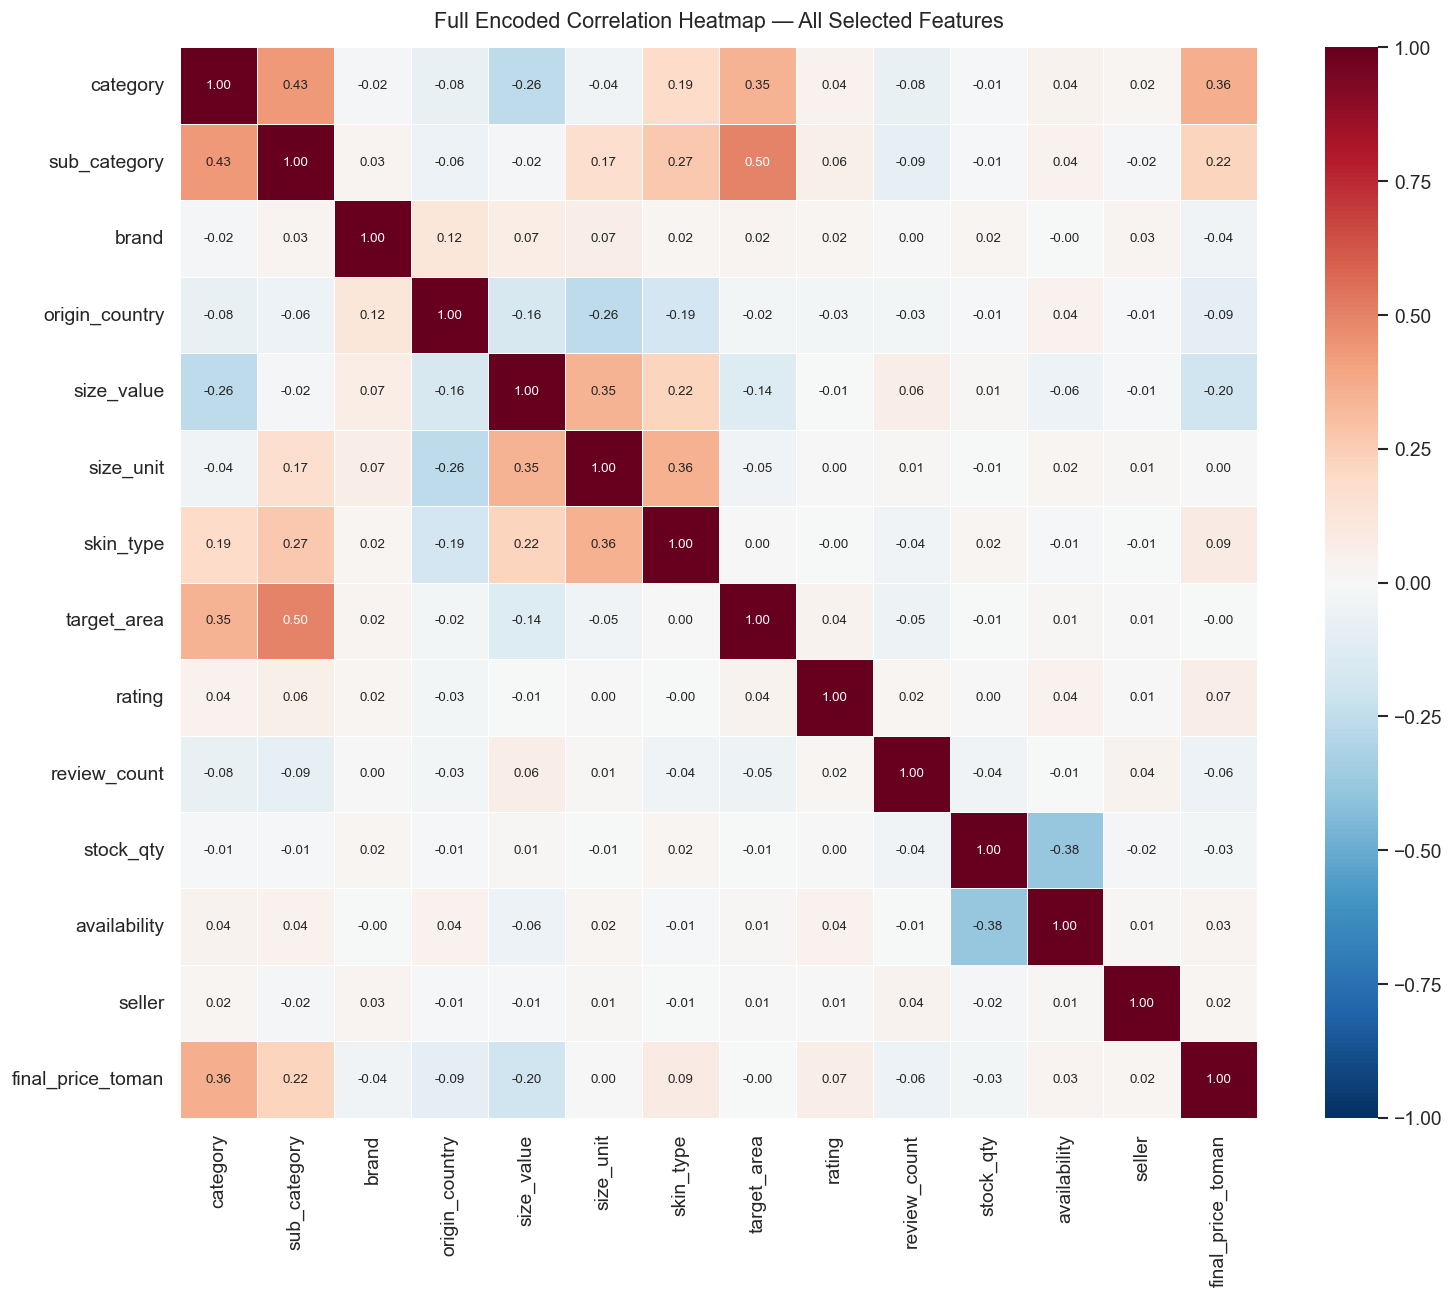

In [14]:
# Build an encoded copy for correlation analysis only
FEATURES_FOR_CORR = [
    "category", "sub_category", "brand", "origin_country",
    "size_value", "size_unit", "skin_type", "target_area",
    "rating", "review_count", "stock_qty", "availability", "seller",
    "final_price_toman"
]
df_corr = df[FEATURES_FOR_CORR].copy()

cat_cols_corr = ["category", "sub_category", "brand", "origin_country",
                 "size_unit", "skin_type", "target_area", "availability", "seller"]
for col in cat_cols_corr:
    df_corr[col] = df_corr[col].astype("category").cat.codes

full_corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    full_corr,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot_kws={"size": 8},
    ax=ax
)
ax.set_title("Full Encoded Correlation Heatmap — All Selected Features", pad=12)
plt.tight_layout()
plt.show()

### 3.3 Feature Correlation with Target Variable

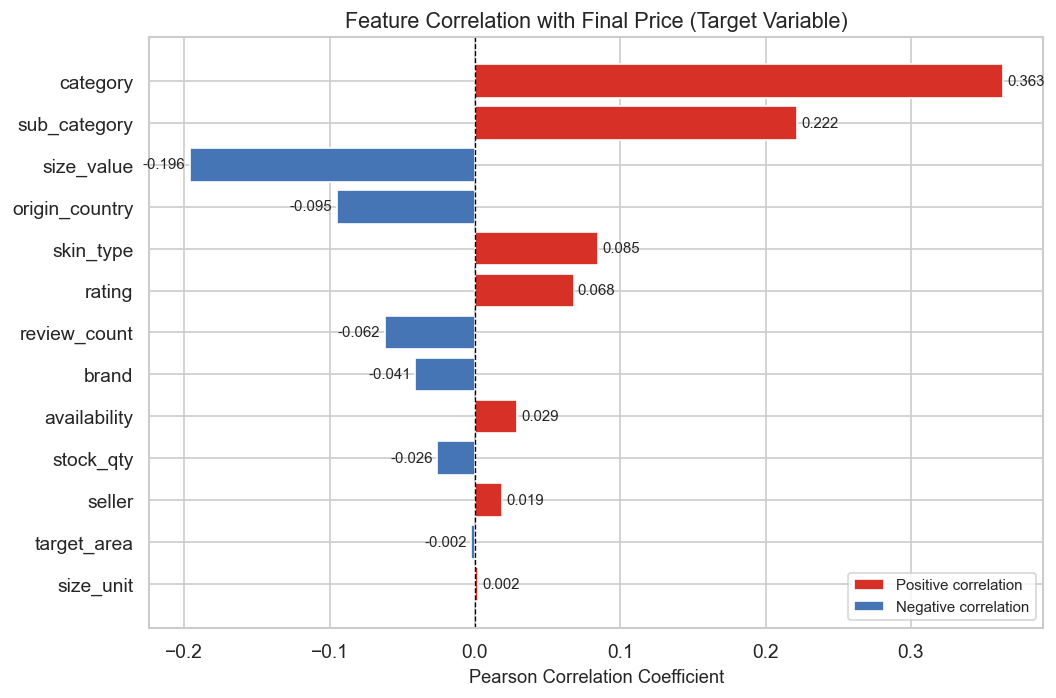


Top 5 features most correlated with final_price_toman:
category          0.363072
sub_category      0.221922
size_value       -0.196096
origin_country   -0.094972
skin_type         0.085036


In [15]:
target_corr = (
    df_corr.corr()["final_price_toman"]
    .drop("final_price_toman")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#d73027" if v > 0 else "#4575b4" for v in target_corr.values]
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, ls="--")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.set_title("Feature Correlation with Final Price (Target Variable)")

for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(val + (0.003 if val >= 0 else -0.003),
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right",
            fontsize=9)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#d73027", label="Positive correlation"),
    Patch(facecolor="#4575b4", label="Negative correlation"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 features most correlated with final_price_toman:")
print(target_corr.head(5).to_string())

## 4. Feature Engineering & Preprocessing

### 4.1 Feature Selection Rationale

In [16]:
# ── Excluded columns (data leakage or identifiers) ────────────────────────────
EXCLUDED = [
    "product_id",        # unique identifier — no predictive value
    "sku",               # unique identifier
    "product_name_fa",   # high cardinality free text
    "variant",           # largely overlaps with sub_category
    "price_toman",       # DATA LEAKAGE: final_price = price × (1 − discount)
    "discount_percent",  # DATA LEAKAGE: see above
    "created_at",        # will be used for feature engineering below
    "updated_at",        # will be used for feature engineering below
]

# ── Selected features ──────────────────────────────────────────────────────────
SELECTED_FEATURES = [
    # High importance
    "category",        # Skincare / Makeup / Haircare / Bodycare
    "sub_category",    # Serum / Moisturizer / Sunscreen …
    "brand",           # 33 unique brands
    "origin_country",  # Iran / France / USA / Germany …
    "size_value",      # numeric: volume or weight
    "size_unit",       # ml / g
    # Medium importance
    "skin_type",       # dry / oily / sensitive / all …
    "target_area",     # face / eyes / hair / body / lips …
    "rating",          # product rating 3.5 – 5.0
    "review_count",    # number of user reviews
    # Lower importance (included for completeness)
    "stock_qty",       # stock quantity
    "availability",    # available / out_of_stock
    "seller",          # 5 sellers
    # Engineered feature
    "days_on_market",  # (updated_at - created_at).days
]

TARGET = "final_price_toman"

print(f"Selected features : {len(SELECTED_FEATURES)}")
print(f"Target column     : {TARGET}")

Selected features : 14
Target column     : final_price_toman


### 4.2 Feature Engineering

days_on_market — min: 0   max: 734   mean: 199.3


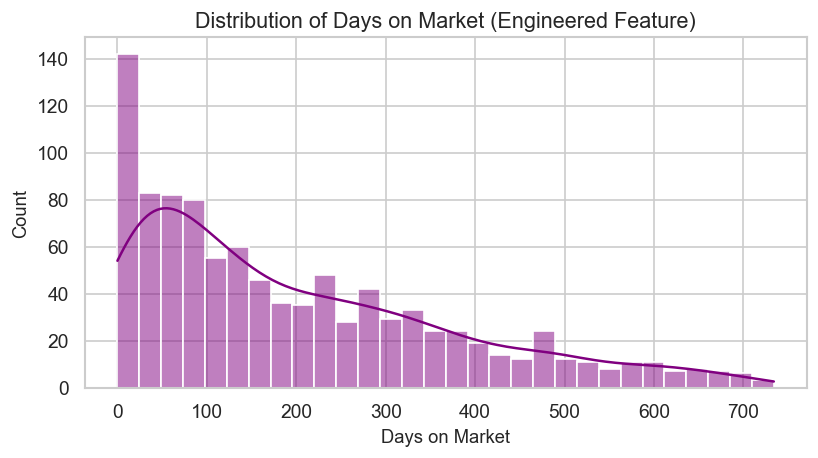

In [17]:
df["days_on_market"] = (df["updated_at"] - df["created_at"]).dt.days

print(f"days_on_market — min: {df['days_on_market'].min()} "
      f"  max: {df['days_on_market'].max()} "
      f"  mean: {df['days_on_market'].mean():.1f}")

fig, ax = plt.subplots(figsize=FIGSIZE_SM)
sns.histplot(df["days_on_market"].dropna(), bins=30, kde=True,
             color="purple", edgecolor="white", ax=ax)
ax.set_title("Distribution of Days on Market (Engineered Feature)")
ax.set_xlabel("Days on Market")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 4.3 Build Feature Matrix

In [18]:
# ── Full dataframe with selected features ─────────────────────────────────────
df_model = df[SELECTED_FEATURES + [TARGET]].copy()
df_model = df_model.dropna().reset_index(drop=True)

print(f"Modelling dataset shape: {df_model.shape}")

CAT_FEATURES = [
    "category", "sub_category", "brand", "origin_country",
    "size_unit", "skin_type", "target_area", "availability", "seller"
]
NUM_FEATURES = [f for f in SELECTED_FEATURES if f not in CAT_FEATURES]

print(f"Categorical features ({len(CAT_FEATURES)}): {CAT_FEATURES}")
print(f"Numeric features    ({len(NUM_FEATURES)}): {NUM_FEATURES}")

Modelling dataset shape: (1000, 15)
Categorical features (9): ['category', 'sub_category', 'brand', 'origin_country', 'size_unit', 'skin_type', 'target_area', 'availability', 'seller']
Numeric features    (5): ['size_value', 'rating', 'review_count', 'stock_qty', 'days_on_market']


### 4.4 Encoding for Random Forest & XGBoost

In [19]:
# OrdinalEncoder maps each category to an integer
# Unknown categories at test time get value –1
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_raw = df_model[SELECTED_FEATURES].copy()
y     = df_model[TARGET].copy()

# Make a copy for RF / XGBoost (encoded)
X_encoded = X_raw.copy()
X_encoded[CAT_FEATURES] = enc.fit_transform(X_raw[CAT_FEATURES].astype(str))
X_encoded = X_encoded.astype(float)

# Make a copy for CatBoost (keeps strings in categorical columns)
X_catboost = X_raw.copy()
for col in CAT_FEATURES:
    X_catboost[col] = X_catboost[col].astype(str)

print("Encoded dataset (RF / XGBoost):")
print(X_encoded.dtypes.to_string())
print()
print(f"CatBoost dataset — shape: {X_catboost.shape}")

Encoded dataset (RF / XGBoost):
category          float64
sub_category      float64
brand             float64
origin_country    float64
size_value        float64
size_unit         float64
skin_type         float64
target_area       float64
rating            float64
review_count      float64
stock_qty         float64
availability      float64
seller            float64
days_on_market    float64

CatBoost dataset — shape: (1000, 14)


### 4.5 Train / Test Split

In [20]:
X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# CatBoost split (same indices)
X_train_cb = X_catboost.loc[X_train_enc.index]
X_test_cb  = X_catboost.loc[X_test_enc.index]

print(f"Train set : {X_train_enc.shape[0]:,} samples")
print(f"Test  set : {X_test_enc.shape[0]:,} samples")
print(f"Target (train) — mean: {y_train.mean():,.0f}  std: {y_train.std():,.0f}")
print(f"Target (test)  — mean: {y_test.mean():,.0f}  std: {y_test.std():,.0f}")

Train set : 800 samples
Test  set : 200 samples
Target (train) — mean: 405,263  std: 220,347
Target (test)  — mean: 403,723  std: 227,565


## 5. Model Training

### 5.1 Random Forest Regressor

Random Forest builds an ensemble of decision trees on random subsets of data and features,
averaging their predictions to reduce variance.

**Hyperparameter tuning strategy:** `RandomizedSearchCV` with `n_iter=20`, `cv=3`
searches a broad parameter space (n_estimators, max_depth, min_samples_split,
min_samples_leaf, max_features) and selects the combination with the highest CV R².
The best estimator is then evaluated on the held-out test set.

In [21]:
# ── Hyperparameter search space ───────────────────────────────────────────────
rf_param_dist = {
    "n_estimators"     : [100, 200, 300, 500],
    "max_depth"        : [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4],
    "max_features"     : ["sqrt", "log2"],
}

print("Searching best hyperparameters for Random Forest (n_iter=20, cv=3)...")
rf_search = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter              = 20,
    cv                  = 3,
    scoring             = "r2",
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
    verbose             = 1,
)
rf_search.fit(X_train_enc, y_train)

rf_best_params = rf_search.best_params_
print(f"\nBest params : {rf_best_params}")
print(f"Best CV R²  : {rf_search.best_score_:.4f}")

# ── Final model — best_estimator_ is already refit on the full train set ──────
rf_model = rf_search.best_estimator_

rf_train_pred = rf_model.predict(X_train_enc)
rf_test_pred  = rf_model.predict(X_test_enc)

rf_train_r2  = r2_score(y_train, rf_train_pred)
rf_test_r2   = r2_score(y_test,  rf_test_pred)
rf_test_mae  = mean_absolute_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_test_mape = np.mean(np.abs((y_test - rf_test_pred) / y_test)) * 100

print("\n" + "=" * 47)
print("Random Forest — Best Model on Test Set")
print("=" * 47)
print(f"  Train R²  : {rf_train_r2:.4f}")
print(f"  Test  R²  : {rf_test_r2:.4f}")
print(f"  MAE       : {rf_test_mae:>12,.0f} Toman")
print(f"  RMSE      : {rf_test_rmse:>12,.0f} Toman")
print(f"  MAPE      : {rf_test_mape:>11.2f} %")

Searching best hyperparameters for Random Forest (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²  : 0.3941

Random Forest — Best Model on Test Set
  Train R²  : 0.8409
  Test  R²  : 0.3850
  MAE       :      137,883 Toman
  RMSE      :      178,013 Toman
  MAPE      :       43.56 %


### 5.2 XGBoost Regressor

XGBoost is a gradient-boosted tree algorithm that builds trees sequentially, each correcting
the errors of the previous ones. It is known for strong performance on tabular data.

**Hyperparameter tuning strategy:** `RandomizedSearchCV` with `n_iter=20`, `cv=3`
searches over n_estimators, learning_rate, max_depth, subsample, colsample_bytree,
reg_alpha, reg_lambda, min_child_weight, and gamma.

In [22]:
# ── Hyperparameter search space ───────────────────────────────────────────────
xgb_param_dist = {
    "n_estimators"    : [100, 200, 300],
    "learning_rate"   : [0.01, 0.05, 0.1, 0.2],
    "max_depth"       : [3, 4, 5, 6],
    "subsample"       : [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "reg_alpha"       : [0, 0.1, 0.5, 1.0],
    "reg_lambda"      : [1.0, 3.0, 5.0],
    "min_child_weight": [1, 5, 10],
    "gamma"           : [0, 0.5, 1.0],
}

print("Searching best hyperparameters for XGBoost (n_iter=20, cv=3)...")
xgb_search = RandomizedSearchCV(
    estimator           = XGBRegressor(
                              random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
    param_distributions = xgb_param_dist,
    n_iter              = 20,
    cv                  = 3,
    scoring             = "r2",
    random_state        = RANDOM_STATE,
    n_jobs              = 1,
    verbose             = 1,
)
xgb_search.fit(X_train_enc, y_train)

xgb_best_params = xgb_search.best_params_
print(f"\nBest params : {xgb_best_params}")
print(f"Best CV R²  : {xgb_search.best_score_:.4f}")

# ── Final model ───────────────────────────────────────────────────────────────
xgb_model = xgb_search.best_estimator_

xgb_train_pred = xgb_model.predict(X_train_enc)
xgb_test_pred  = xgb_model.predict(X_test_enc)

xgb_train_r2  = r2_score(y_train, xgb_train_pred)
xgb_test_r2   = r2_score(y_test,  xgb_test_pred)
xgb_test_mae  = mean_absolute_error(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_test_mape = np.mean(np.abs((y_test - xgb_test_pred) / y_test)) * 100

print("\n" + "=" * 47)
print("XGBoost — Best Model on Test Set")
print("=" * 47)
print(f"  Train R²  : {xgb_train_r2:.4f}")
print(f"  Test  R²  : {xgb_test_r2:.4f}")
print(f"  MAE       : {xgb_test_mae:>12,.0f} Toman")
print(f"  RMSE      : {xgb_test_rmse:>12,.0f} Toman")
print(f"  MAPE      : {xgb_test_mape:>11.2f} %")

Searching best hyperparameters for XGBoost (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV R²  : 0.4106

XGBoost — Best Model on Test Set
  Train R²  : 0.5565
  Test  R²  : 0.3950
  MAE       :      137,452 Toman
  RMSE      :      176,557 Toman
  MAPE      :       43.67 %


### 5.3 CatBoost Regressor

CatBoost is a gradient-boosting library designed for datasets with categorical features.
It uses an ordered target encoding technique that avoids target leakage during training,
making it especially suitable for this dataset which has 9 categorical columns.

**Hyperparameter tuning strategy (two-step):**
1. `RandomizedSearchCV` (`n_iter=20`, `cv=3`) on OrdinalEncoded data finds the best
   structural parameters (iterations, learning_rate, depth, l2_leaf_reg).
2. The final model is retrained with those best params **plus** native `cat_features`,
   giving CatBoost the full benefit of its internal categorical encoding.

In [23]:
# ── Step 1 — find best structural hyperparams via RandomizedSearchCV ──────────
# Encoded data is used for search so sklearn's CV mechanism works correctly.
cb_param_dist = {
    "iterations"   : [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "depth"        : [4, 6, 8],
    "l2_leaf_reg"  : [1, 3, 5, 10],
}

print("Searching best hyperparameters for CatBoost (n_iter=20, cv=3)...")
cb_search = RandomizedSearchCV(
    estimator           = CatBoostRegressor(random_seed=RANDOM_STATE, verbose=0),
    param_distributions = cb_param_dist,
    n_iter              = 20,
    cv                  = 3,
    scoring             = "r2",
    random_state        = RANDOM_STATE,
    n_jobs              = 1,
    verbose             = 1,
)
cb_search.fit(X_train_enc, y_train)

cb_best_params = cb_search.best_params_
print(f"\nBest params : {cb_best_params}")
print(f"Best CV R²  : {cb_search.best_score_:.4f}")

# ── Step 2 — retrain with best params + native categorical handling ────────────
print("\nRetraining final CatBoost with cat_features enabled...")
cb_model = CatBoostRegressor(
    **cb_best_params,
    loss_function = "RMSE",
    eval_metric   = "RMSE",
    cat_features  = CAT_FEATURES,
    random_seed   = RANDOM_STATE,
    verbose       = 100,
)
cb_model.fit(X_train_cb, y_train, eval_set=(X_test_cb, y_test))

cb_train_pred = cb_model.predict(X_train_cb)
cb_test_pred  = cb_model.predict(X_test_cb)

cb_train_r2  = r2_score(y_train, cb_train_pred)
cb_test_r2   = r2_score(y_test,  cb_test_pred)
cb_test_mae  = mean_absolute_error(y_test, cb_test_pred)
cb_test_rmse = np.sqrt(mean_squared_error(y_test, cb_test_pred))
cb_test_mape = np.mean(np.abs((y_test - cb_test_pred) / y_test)) * 100

print("\n" + "=" * 47)
print("CatBoost — Best Model on Test Set")
print("=" * 47)
print(f"  Train R²  : {cb_train_r2:.4f}")
print(f"  Test  R²  : {cb_test_r2:.4f}")
print(f"  MAE       : {cb_test_mae:>12,.0f} Toman")
print(f"  RMSE      : {cb_test_rmse:>12,.0f} Toman")
print(f"  MAPE      : {cb_test_mape:>11.2f} %")

Searching best hyperparameters for CatBoost (n_iter=20, cv=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 300, 'depth': 4}
Best CV R²  : 0.4103

Retraining final CatBoost with cat_features enabled...
0:	learn: 217069.2917344	test: 223765.6962952	best: 223765.6962952 (0)	total: 10.4ms	remaining: 3.1s
100:	learn: 159354.2292390	test: 174421.3657812	best: 174421.3657812 (100)	total: 1.07s	remaining: 2.11s
200:	learn: 151083.7813065	test: 173286.0425011	best: 173183.4637016 (180)	total: 2.1s	remaining: 1.03s
299:	learn: 145739.7788139	test: 173236.8019930	best: 173076.4781806 (248)	total: 3.09s	remaining: 0us

bestTest = 173076.4782
bestIteration = 248

Shrink model to first 249 iterations.

CatBoost — Best Model on Test Set
  Train R²  : 0.5492
  Test  R²  : 0.4186
  MAE       :      136,102 Toman
  RMSE      :      173,076 Toman
  MAPE      :       42.46 %


## 6. Model Evaluation & Comparison

### 6.1 Metrics Summary Table

In [24]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "CatBoost"],
    "Train R²": [rf_train_r2,  xgb_train_r2,  cb_train_r2],
    "Test R²":  [rf_test_r2,   xgb_test_r2,   cb_test_r2],
    "MAE (Toman)":  [rf_test_mae,  xgb_test_mae,  cb_test_mae],
    "RMSE (Toman)": [rf_test_rmse, xgb_test_rmse, cb_test_rmse],
    "MAPE (%)": [rf_test_mape, xgb_test_mape, cb_test_mape],
}).set_index("Model")

for col in ["Train R²", "Test R²"]:
    results[col] = results[col].map("{:.4f}".format)
results["MAE (Toman)"]  = results["MAE (Toman)"].map("{:,.0f}".format)
results["RMSE (Toman)"] = results["RMSE (Toman)"].map("{:,.0f}".format)
results["MAPE (%)"]     = results["MAPE (%)"].map("{:.2f}".format)

print(results.to_string())
results

              Train R² Test R² MAE (Toman) RMSE (Toman) MAPE (%)
Model                                                           
Random Forest   0.8409  0.3850     137,883      178,013    43.56
XGBoost         0.5565  0.3950     137,452      176,557    43.67
CatBoost        0.5492  0.4186     136,102      173,076    42.46


,Train R²,Test R²,MAE (Toman),RMSE (Toman),MAPE (%)
Model,,,,,
Random Forest,0.8409,0.3850,"137,883","178,013",43.56
XGBoost,0.5565,0.3950,"137,452","176,557",43.67
CatBoost,0.5492,0.4186,"136,102","173,076",42.46


### 6.2 Metrics Comparison — Bar Charts

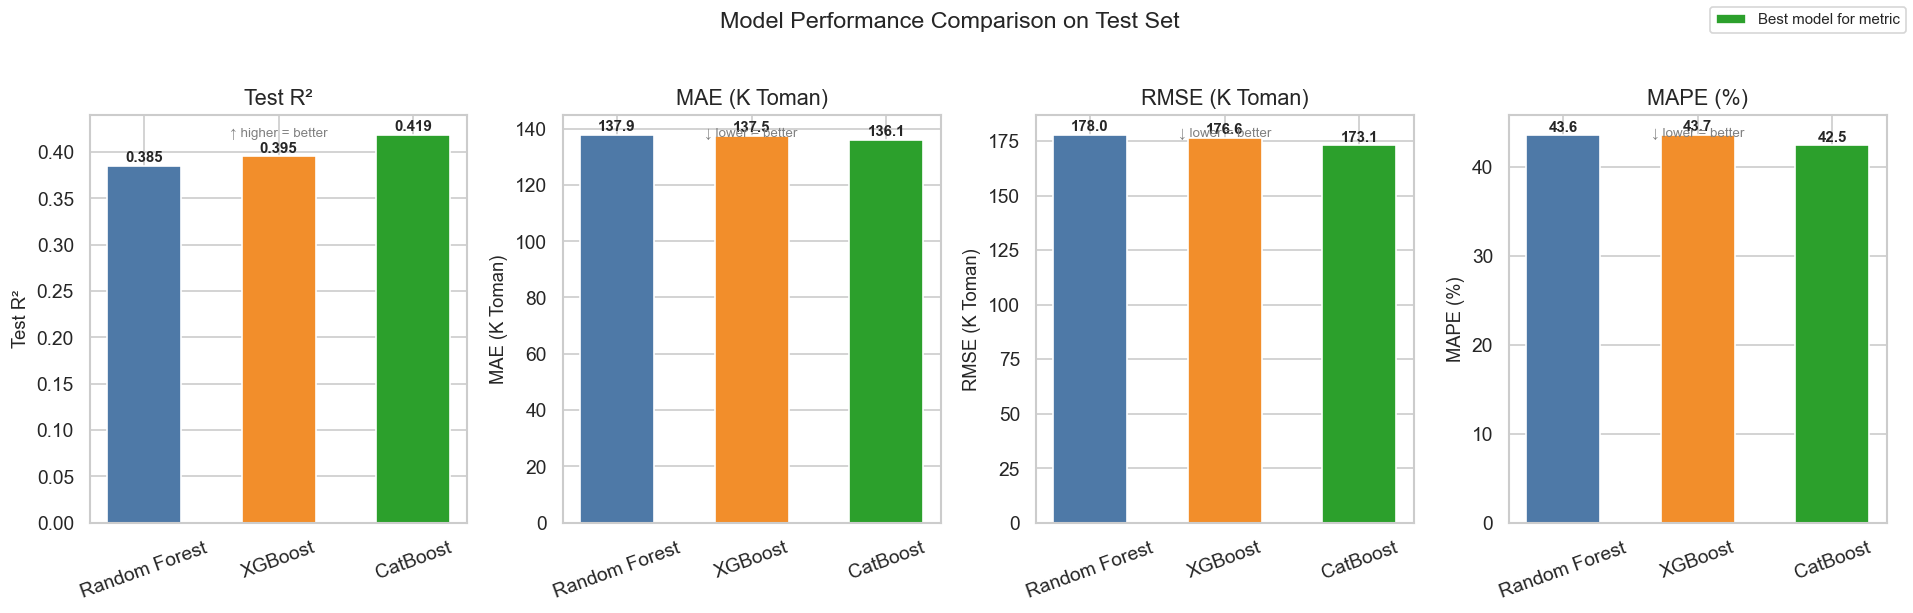

In [25]:
# Recompute as floats for plotting
metrics_float = {
    "Model":       ["Random Forest", "XGBoost", "CatBoost"],
    "Test R²":     [rf_test_r2,  xgb_test_r2,  cb_test_r2],
    "MAE (K Toman)": [rf_test_mae/1000, xgb_test_mae/1000, cb_test_mae/1000],
    "RMSE (K Toman)":[rf_test_rmse/1000, xgb_test_rmse/1000, cb_test_rmse/1000],
    "MAPE (%)":    [rf_test_mape, xgb_test_mape, cb_test_mape],
}
mf = pd.DataFrame(metrics_float).set_index("Model")

palette_3 = ["#4e79a7", "#f28e2b", "#e15759"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
titles   = list(mf.columns)
y_labels = list(mf.columns)
higher_better = [True, False, False, False]

for ax, col, hb in zip(axes, titles, higher_better):
    vals = mf[col]
    best = vals.idxmax() if hb else vals.idxmin()
    colors = [
        "#2ca02c" if idx == best else c
        for idx, c in zip(mf.index, palette_3)
    ]
    bars = ax.bar(mf.index, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max()*0.01,
                f"{bar.get_height():.3f}" if "R²" in col else f"{bar.get_height():.1f}",
                ha="center", fontsize=9, fontweight="bold")
    note = "↑ higher = better" if hb else "↓ lower = better"
    ax.text(0.5, 0.97, note, ha="center", va="top",
            transform=ax.transAxes, fontsize=8, color="gray")

from matplotlib.patches import Patch
legend_patches = [Patch(facecolor="#2ca02c", label="Best model for metric")]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9)
fig.suptitle("Model Performance Comparison on Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Feature Importance Comparison

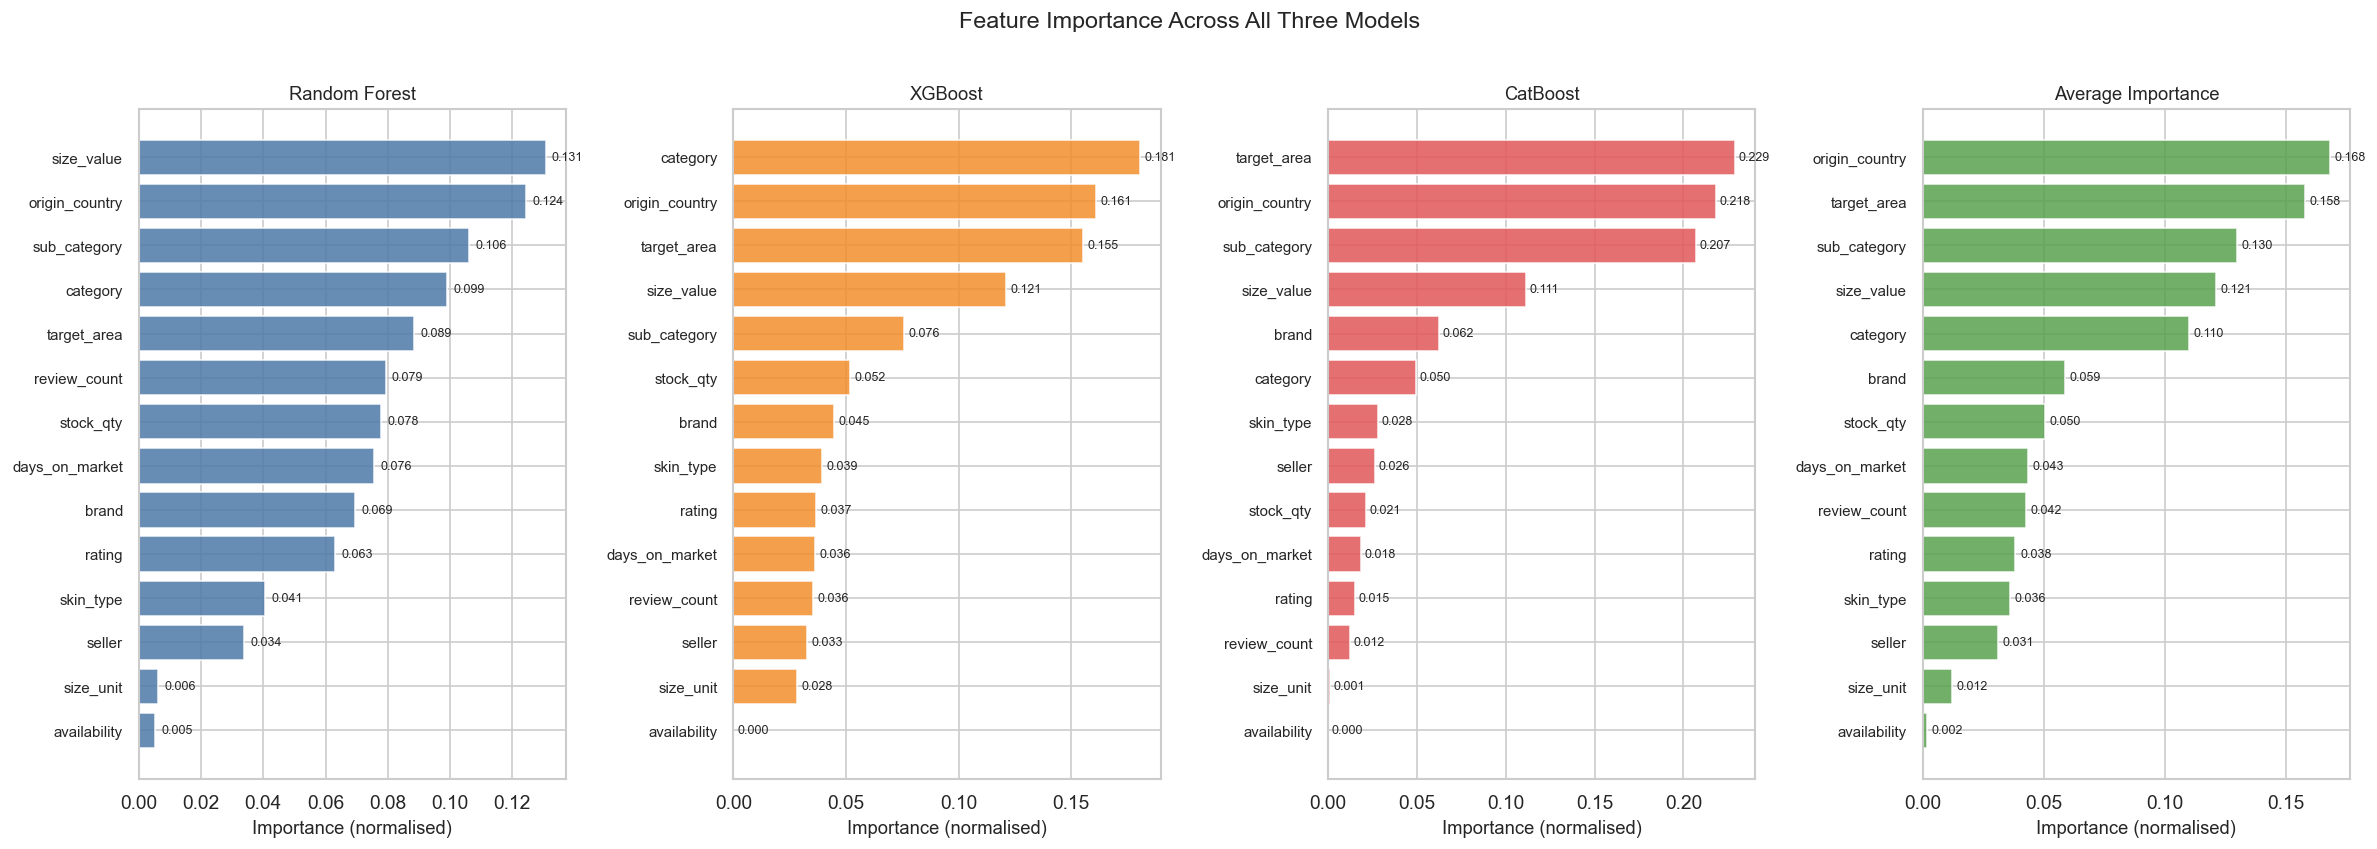

In [26]:
rf_imp  = pd.Series(rf_model.feature_importances_,  index=SELECTED_FEATURES)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=SELECTED_FEATURES)
cb_imp  = pd.Series(cb_model.get_feature_importance(), index=SELECTED_FEATURES)

# Normalise to 0–1
rf_imp  = rf_imp  / rf_imp.sum()
xgb_imp = xgb_imp / xgb_imp.sum()
cb_imp  = cb_imp  / cb_imp.sum()

# Average importance across models
avg_imp = (rf_imp + xgb_imp + cb_imp) / 3
avg_imp = avg_imp.sort_values(ascending=True)

fig, axes = plt.subplots(1, 4, figsize=(20, 7))
data_pairs = [
    (rf_imp.sort_values(ascending=True),  "Random Forest",     "#4e79a7"),
    (xgb_imp.sort_values(ascending=True), "XGBoost",           "#f28e2b"),
    (cb_imp.sort_values(ascending=True),  "CatBoost",          "#e15759"),
    (avg_imp,                             "Average Importance", "#59a14f"),
]

for ax, (imp, title, color) in zip(axes, data_pairs):
    ax.barh(imp.index, imp.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Importance (normalised)")
    ax.tick_params(axis="y", labelsize=9)
    for i, (idx, val) in enumerate(imp.items()):
        ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=7.5)

fig.suptitle("Feature Importance Across All Three Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.4 Actual vs Predicted Scatter Plots

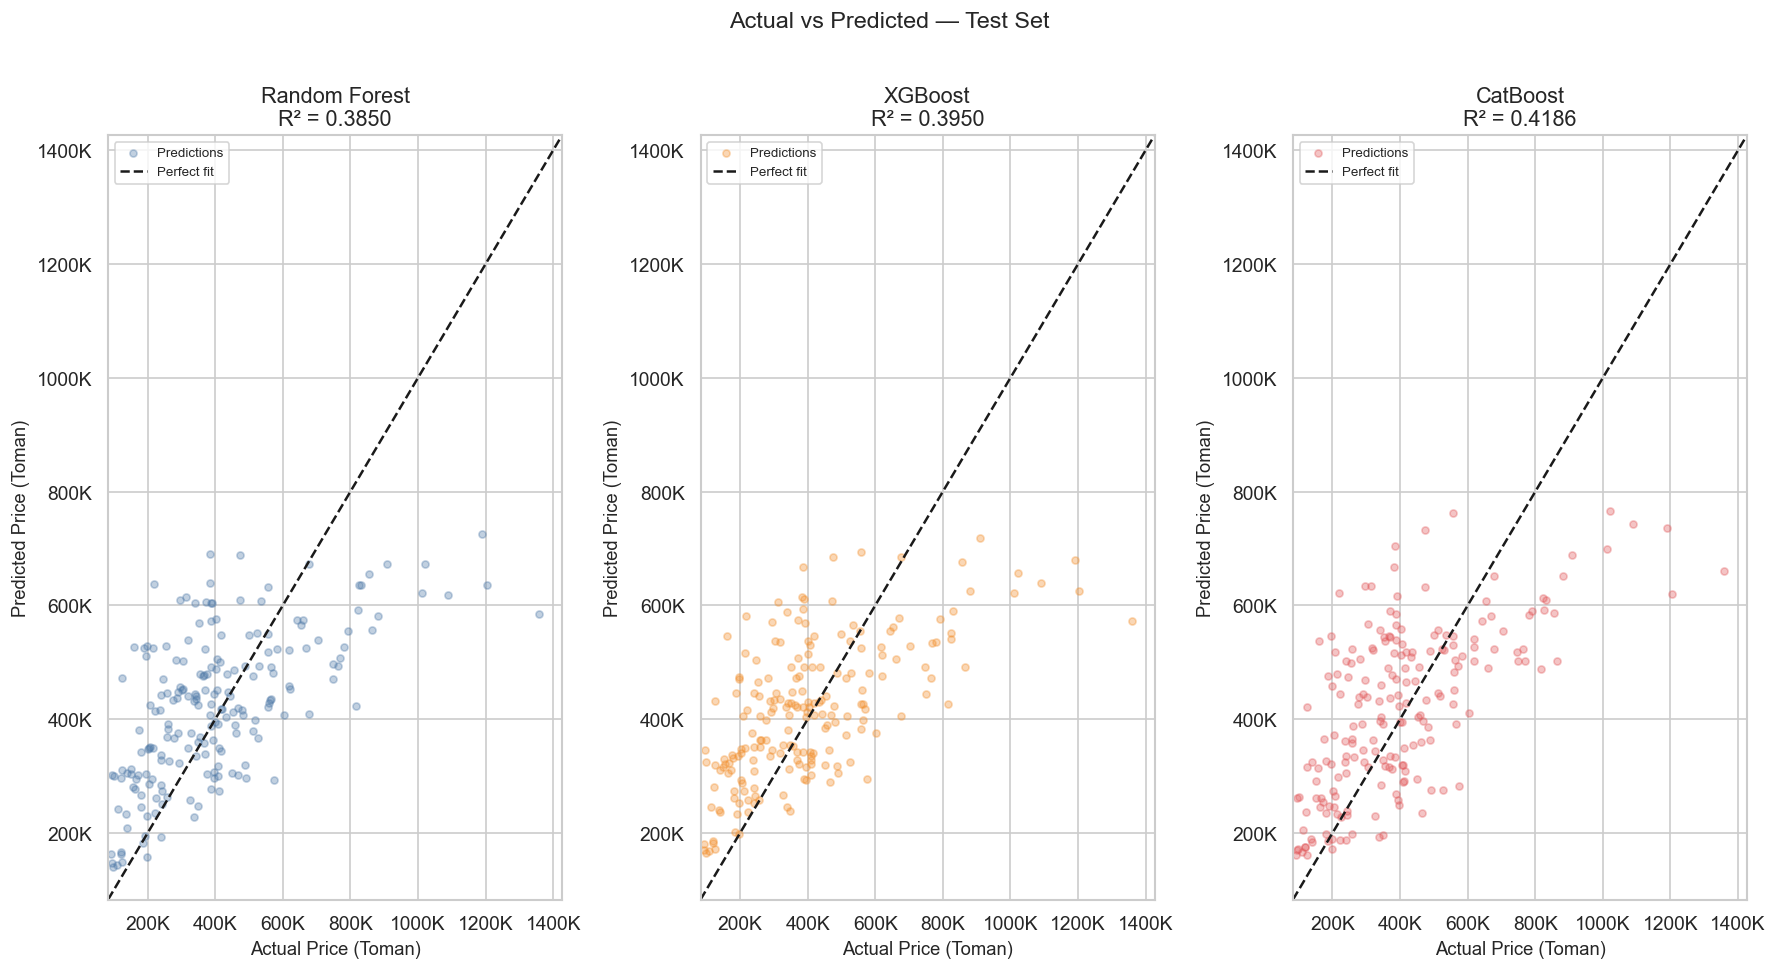

In [27]:
fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_XL)

models_pred = [
    ("Random Forest", rf_test_pred,  rf_test_r2,  "#4e79a7"),
    ("XGBoost",       xgb_test_pred, xgb_test_r2, "#f28e2b"),
    ("CatBoost",      cb_test_pred,  cb_test_r2,  "#e15759"),
]

y_min = y_test.min() * 0.9
y_max = y_test.max() * 1.05

for ax, (name, pred, r2, color) in zip(axes, models_pred):
    ax.scatter(y_test, pred, alpha=0.35, s=18, color=color, label="Predictions")
    ax.plot([y_min, y_max], [y_min, y_max], "k--", lw=1.5, label="Perfect fit")
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(y_min, y_max)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
    ax.set_xlabel("Actual Price (Toman)")
    ax.set_ylabel("Predicted Price (Toman)")
    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.legend(fontsize=8)

fig.suptitle("Actual vs Predicted — Test Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Residual Analysis

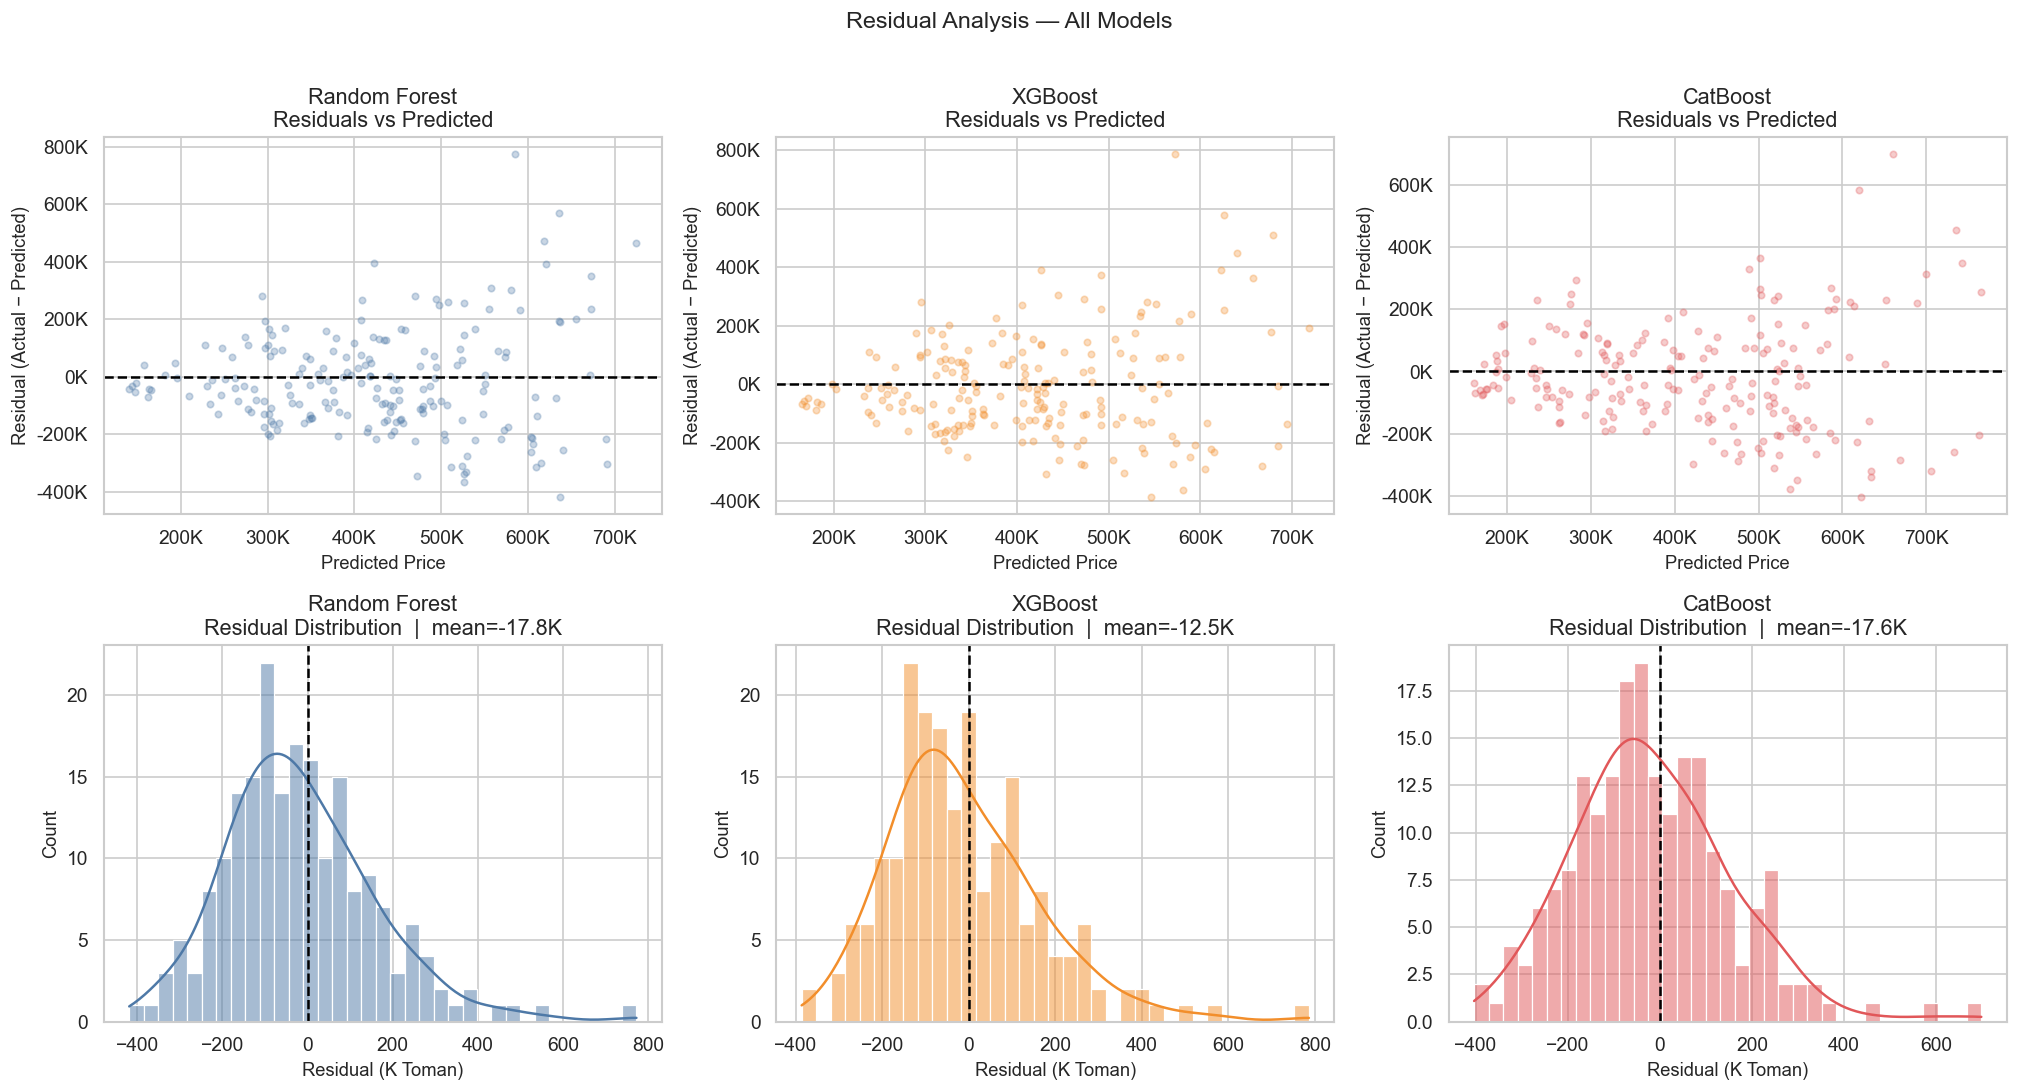

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for col, (name, pred, r2_val, color) in enumerate(models_pred):
    residuals = y_test.values - pred

    # Residuals vs Predicted
    ax = axes[0, col]
    ax.scatter(pred, residuals, alpha=0.3, s=15, color=color)
    ax.axhline(0, color="black", lw=1.5, ls="--")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
    ax.set_xlabel("Predicted Price")
    ax.set_ylabel("Residual (Actual − Predicted)")
    ax.set_title(f"{name}\nResiduals vs Predicted")

    # Residual distribution
    ax2 = axes[1, col]
    sns.histplot(residuals/1000, bins=35, kde=True, color=color,
                 edgecolor="white", ax=ax2)
    ax2.axvline(0, color="black", lw=1.5, ls="--")
    ax2.set_xlabel("Residual (K Toman)")
    ax2.set_ylabel("Count")
    ax2.set_title(f"{name}\nResidual Distribution  |  mean={residuals.mean()/1000:.1f}K")

fig.suptitle("Residual Analysis — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 6.6 K-Fold Cross-Validation (5-Fold)

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Running 5-Fold Cross-Validation with best hyperparameters...")
print()

cv_results = {}

# ── Random Forest — uses best_estimator_ directly ────────────────────────────
rf_cv = cross_val_score(rf_model, X_encoded, y,
                        cv=kf, scoring="r2", n_jobs=-1)
cv_results["Random Forest"] = rf_cv
print(f"Random Forest — CV R²: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}  "
      f"| folds: {np.round(rf_cv, 4)}")

# ── XGBoost — fresh model with best params (no eval_set for CV) ───────────────
xgb_cv_model = XGBRegressor(
    **xgb_best_params,
    random_state=RANDOM_STATE, n_jobs=1, verbosity=0,
)
xgb_cv = cross_val_score(xgb_cv_model, X_encoded, y,
                         cv=kf, scoring="r2", n_jobs=1)
cv_results["XGBoost"] = xgb_cv
print(f"XGBoost       — CV R²: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}  "
      f"| folds: {np.round(xgb_cv, 4)}")

# ── CatBoost — fresh model with best structural params, encoded data ──────────
cb_cv_model = CatBoostRegressor(
    **cb_best_params,
    random_seed=RANDOM_STATE, verbose=0,
)
cb_cv = cross_val_score(cb_cv_model, X_encoded, y,
                        cv=kf, scoring="r2", n_jobs=1)
cv_results["CatBoost"] = cb_cv
print(f"CatBoost      — CV R²: {cb_cv.mean():.4f} ± {cb_cv.std():.4f}  "
      f"| folds: {np.round(cb_cv, 4)}")

Running 5-Fold Cross-Validation with best hyperparameters...

Random Forest — CV R²: 0.3933 ± 0.0561  | folds: [0.3853 0.3987 0.4734 0.2988 0.41  ]
XGBoost       — CV R²: 0.4158 ± 0.0407  | folds: [0.3902 0.4365 0.4634 0.3496 0.4395]
CatBoost      — CV R²: 0.4203 ± 0.0561  | folds: [0.4061 0.4491 0.4695 0.3167 0.4597]


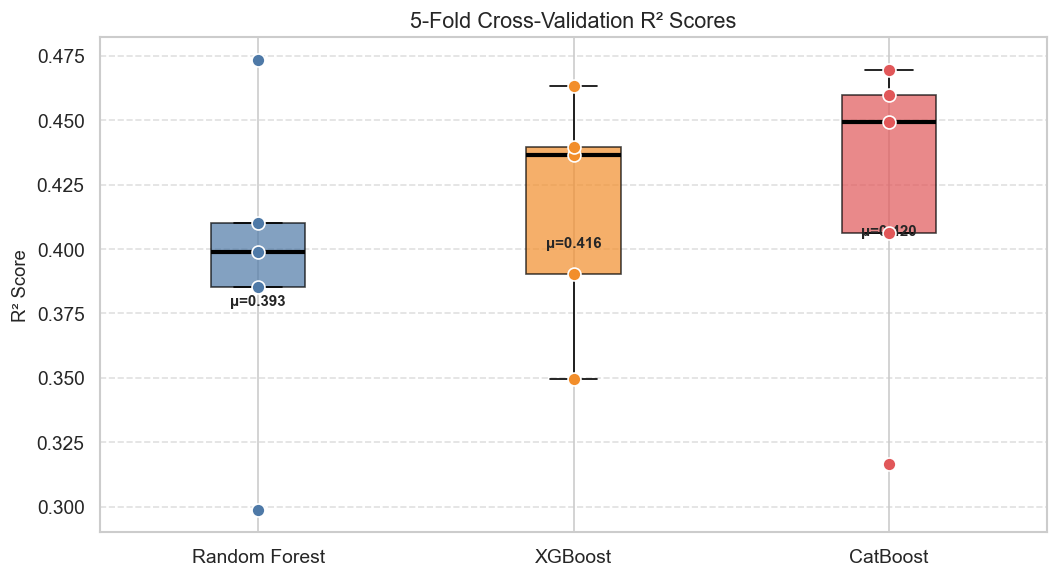

In [30]:
# Cross-validation box plots
fig, ax = plt.subplots(figsize=(9, 5))

cv_df = pd.DataFrame(cv_results)
bp = ax.boxplot(
    [cv_df[c] for c in cv_df.columns],
    patch_artist=True, notch=False,
    labels=cv_df.columns,
    medianprops=dict(color="black", linewidth=2.5)
)
colors_box = ["#4e79a7", "#f28e2b", "#e15759"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Overlay individual fold scores
for i, (col, color) in enumerate(zip(cv_df.columns, colors_box), start=1):
    ax.scatter([i]*5, cv_df[col], color=color, s=60, zorder=5,
               edgecolors="white", linewidths=1)

ax.set_ylabel("R² Score")
ax.set_title("5-Fold Cross-Validation R² Scores")
ax.yaxis.grid(True, linestyle="--", alpha=0.6)

# Annotate means
for i, col in enumerate(cv_df.columns, start=1):
    mean_val = cv_df[col].mean()
    ax.text(i, mean_val - 0.015, f"μ={mean_val:.3f}",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

### 6.7 Final Comparison Summary

In [33]:
# ── Ranked summary table (no .style / no jinja2 required) ────────────────────
models_list = ["Random Forest", "XGBoost", "CatBoost"]

summary_raw = pd.DataFrame({
    "Model"     : models_list,
    "Train R²"  : [rf_train_r2,  xgb_train_r2,  cb_train_r2],
    "Test R²"   : [rf_test_r2,   xgb_test_r2,   cb_test_r2],
    "CV R² mean": [rf_cv.mean(), xgb_cv.mean(),  cb_cv.mean()],
    "MAE"       : [rf_test_mae,  xgb_test_mae,   cb_test_mae],
    "RMSE"      : [rf_test_rmse, xgb_test_rmse,  cb_test_rmse],
    "MAPE (%)"  : [rf_test_mape, xgb_test_mape,  cb_test_mape],
})

# Per-metric ranks (1 = best)
rank_def = {
    "Test R²"   : False,   # higher → better
    "CV R² mean": False,
    "MAE"       : True,    # lower  → better
    "RMSE"      : True,
    "MAPE (%)"  : True,
}
for col, asc in rank_def.items():
    summary_raw[f"_r_{col}"] = summary_raw[col].rank(ascending=asc).astype(int)

summary_raw["Overall Rank"] = (
    summary_raw[[f"_r_{c}" for c in rank_def]].mean(axis=1)
    .rank(ascending=True).astype(int)
)
summary_raw.drop(columns=[f"_r_{c}" for c in rank_def], inplace=True)
summary_raw = summary_raw.sort_values("Overall Rank").reset_index(drop=True)

MEDALS = {1: "🥇", 2: "🥈", 3: "🥉"}
summary_raw.insert(0, "Medal", summary_raw["Overall Rank"].map(MEDALS))

# Formatted display copy
disp = summary_raw.copy()
disp["Train R²"]   = disp["Train R²"].map("{:.4f}".format)
disp["Test R²"]    = disp["Test R²"].map("{:.4f}".format)
disp["CV R² mean"] = disp["CV R² mean"].map("{:.4f}".format)
disp["MAE"]        = disp["MAE"].map("{:,.0f}".format)
disp["RMSE"]       = disp["RMSE"].map("{:,.0f}".format)
disp["MAPE (%)"]   = disp["MAPE (%)"].map("{:.2f}".format)
disp.rename(columns={"MAE": "MAE (Toman)", "RMSE": "RMSE (Toman)"}, inplace=True)
disp = disp.set_index("Medal")

print(disp.to_string())
# disp

               Model Train R² Test R² CV R² mean MAE (Toman) RMSE (Toman) MAPE (%)  Overall Rank
Medal                                                                                           
🥇           CatBoost   0.5492  0.4186     0.4203     136,102      173,076    42.46             1
🥈            XGBoost   0.5565  0.3950     0.4158     137,452      176,557    43.67             2
🥉      Random Forest   0.8409  0.3850     0.3933     137,883      178,013    43.56             3
